<a href="https://colab.research.google.com/github/wondertyrant-creator/Flight-data-analysis/blob/main/flight_analysis_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SECTION 1: IMPORTS AND DATA LOADING**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('/content/flight_data_2024.csv', dtype={'cancellation_code': str}, low_memory=False)
df['fl_date'] = pd.to_datetime(df['fl_date'], dayfirst=True, format='mixed')

**SECTION 2: INITIAL DATA EXPLORATION**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 35 columns):
 #   Column               Dtype         
---  ------               -----         
 0   year                 int64         
 1   month                int64         
 2   day_of_month         int64         
 3   day_of_week          int64         
 4   fl_date              datetime64[ns]
 5   op_unique_carrier    object        
 6   op_carrier_fl_num    float64       
 7   origin               object        
 8   origin_city_name     object        
 9   origin_state_nm      object        
 10  dest                 object        
 11  dest_city_name       object        
 12  dest_state_nm        object        
 13  crs_dep_time         int64         
 14  dep_time             float64       
 15  dep_delay            float64       
 16  taxi_out             float64       
 17  wheels_off           float64       
 18  wheels_on            float64       
 19  taxi_in              

In [5]:
df.shape

(7079081, 35)

In [6]:
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


In [7]:
print(df['op_unique_carrier'].value_counts())

op_unique_carrier
WN    1419419
DL    1009194
AA     984306
UA     760451
OO     744658
YX     301465
MQ     279955
NK     261103
AS     245819
B6     240282
OH     227971
F9     208624
9E     200094
G4     117210
HA      78530
Name: count, dtype: int64


In [8]:
unique_flights_count = df.groupby(['op_unique_carrier', 'op_carrier_fl_num']).ngroups
print(f"\nNumber of unique flight numbers: {unique_flights_count}")


Number of unique flight numbers: 32342


In [9]:
print("\n--- Unique Origin Airports per Carrier ---")
unique_origins_per_carrier = (
    df.groupby('op_unique_carrier')['origin']
    .nunique()
    .sort_values(ascending=False)
    .rename('unique_origins')
)
display(unique_origins_per_carrier)


--- Unique Origin Airports per Carrier ---


,unique_origins
op_unique_carrier,
OO,265
MQ,173
DL,152
AA,134
G4,126
UA,124
9E,123
WN,107
OH,100


In [10]:
print("\n--- Unique Origin Airports per Carrier ---")
unique_origins_per_carrier = (
    df.groupby('op_unique_carrier')['origin']
    .nunique()
    .sort_values(ascending=False)
    .rename('unique_origins')
)
display(unique_origins_per_carrier)


--- Unique Origin Airports per Carrier ---


,unique_origins
op_unique_carrier,
OO,265
MQ,173
DL,152
AA,134
G4,126
UA,124
9E,123
WN,107
OH,100


**SECTION 3: DATA QUALITY**

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

,0
year,0
month,0
day_of_month,0
day_of_week,0
fl_date,0
op_unique_carrier,0
op_carrier_fl_num,1
origin,0
origin_city_name,0
origin_state_nm,0


Null handling for delay columns

In [13]:
DELAY_COLS = ['carrier_delay', 'weather_delay', 'nas_delay',
              'security_delay', 'late_aircraft_delay']
df[DELAY_COLS] = df[DELAY_COLS].fillna(0)

Outlier detection

In [14]:
p99_dep = df['dep_delay'].quantile(0.99)
p99_arr = df['arr_delay'].quantile(0.99)
df['is_outlier'] = (df['dep_delay'] > p99_dep) | (df['arr_delay'] > p99_arr)

In [15]:
outlier_count = df['is_outlier'].sum()
outlier_pct   = outlier_count / len(df) * 100
print(f"\nOutlier threshold  — dep_delay > {p99_dep:.0f} min  OR  arr_delay > {p99_arr:.0f} min")
print(f"Outlier flights    — {outlier_count:,} ({outlier_pct:.2f}% of dataset)")



Outlier threshold  — dep_delay > 216 min  OR  arr_delay > 215 min
Outlier flights    — 74,938 (1.06% of dataset)


In [16]:
print("\nImpact of outliers on avg departure delay per carrier:")
impact = pd.DataFrame({
    'with_outliers':    df.groupby('op_unique_carrier')['dep_delay'].mean().round(2),
    'without_outliers': df[~df['is_outlier']].groupby('op_unique_carrier')['dep_delay'].mean().round(2),
})
impact['difference'] = (impact['with_outliers'] - impact['without_outliers']).round(2)
display(impact.sort_values('difference', ascending=False))


Impact of outliers on avg departure delay per carrier:


,with_outliers,without_outliers,difference
op_unique_carrier,,,
AA,20.70,12.55,8.15
G4,14.05,6.64,7.41
F9,19.00,12.24,6.76
OH,13.94,7.61,6.33
B6,17.46,11.98,5.48
OO,11.28,6.16,5.12
9E,8.34,4.49,3.85
DL,10.22,6.41,3.81
UA,11.96,8.25,3.71


**SECTION 4: FEATURE ENGINEERING**

In [17]:
df['total_delay']      = df['dep_delay'] + df['arr_delay']
df['is_on_time']       = df['arr_delay'] <= 15
df['is_severely_late'] = df['dep_delay'] > 60

In [18]:
delay_mag_bins   = [-float('inf'), 0, 15, 60, 120, float('inf')]
delay_mag_labels = ['Early / On Time', 'Minor (1–15 min)',
                    'Moderate (16–60 min)', 'Severe (61–120 min)', 'Extreme (>120 min)']
df['delay_magnitude'] = pd.cut(df['dep_delay'], bins=delay_mag_bins, labels=delay_mag_labels)

Time features

In [19]:
df['season'] = pd.cut(df['month'],
    bins=[0, 2, 5, 8, 11, 12],
    labels=['Winter', 'Spring', 'Summer', 'Autumn', 'Winter'],
    ordered=False
)

df['season'] = df['season'].astype(str)

In [20]:
df['scheduled_departure_hour'] = df['crs_dep_time'] // 100
df['is_weekend'] = df['day_of_week'].isin([6, 7])

In [21]:
df['day_type'] = df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

Aircraft performance

In [22]:
df['schedule_padding'] = df['crs_elapsed_time'] - df['actual_elapsed_time']
df['ground_speed'] = df['distance'] / df['air_time']

In [23]:
padding_bins   = [-float('inf'), -10, 0, 10, 20, float('inf')]
padding_labels = ['Severely Under-padded (<-10 min)', 'Slightly Under-padded (-10–0 min)',
                  'Tight Padding (0–10 min)', 'Moderate Padding (10–20 min)', 'Heavy Padding (>20 min)']
df['padding_category'] = pd.cut(df['schedule_padding'], bins=padding_bins, labels=padding_labels)

Flight classification

In [24]:
df['flight_type'] = np.where(df['distance'] > 1800, 'Long-haul', 'Short-haul')

Distance bands (used in route analysis)

In [25]:
dist_bins = [0, 500, 1000, 1500, 2000, 3000, float('inf')]
dist_labels = ['<500mi', '500–1000mi', '1000–1500mi', '1500–2000mi', '2000–3000mi', '>3000mi']

In [26]:
df['distance_band'] = pd.cut(df['distance'], bins=dist_bins, labels=dist_labels)

In [27]:
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,delay_magnitude,season,scheduled_departure_hour,is_weekend,day_type,schedule_padding,ground_speed,padding_category,flight_type,distance_band
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,Early / On Time,Winter,12,False,Weekday,14.0,6.059524,Moderate Padding (10–20 min),Short-haul,500–1000mi
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,Early / On Time,Winter,10,False,Weekday,16.0,7.068182,Moderate Padding (10–20 min),Short-haul,500–1000mi
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,Early / On Time,Winter,14,False,Weekday,16.0,4.721311,Moderate Padding (10–20 min),Short-haul,<500mi
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,Early / On Time,Winter,16,False,Weekday,35.0,5.647059,Heavy Padding (>20 min),Short-haul,<500mi
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,Early / On Time,Winter,10,False,Weekday,9.0,5.266667,Tight Padding (0–10 min),Short-haul,<500mi


**SECTION 5: AIRPORT ANALYSIS**

Busiest airports by departure volume

In [28]:
busiest_airports = df['origin'].value_counts().head(10)
display(busiest_airports)

,count
origin,
ATL,341910
DFW,313582
DEN,308645
ORD,280052
CLT,217574
LAX,194053
PHX,193551
LAS,189252
SEA,163725


Longest average taxi-out times

In [29]:
longest_taxi_out = (
    df.groupby('origin')['taxi_out']
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .head(20)
)
display(longest_taxi_out)

,taxi_out
origin,
JFK,26.31
GUC,24.79
EWR,24.29
BGM,24.23
ORD,23.79
LGA,23.46
HDN,23.30
XWA,22.99
ASE,22.29


Airport congestion score

In [30]:
congestion_score = (
    df.groupby('origin')
    .agg(
        avg_taxi_out=('taxi_out', 'mean'),
        avg_nas_delay=('nas_delay', 'mean'),
        flight_volume=('op_carrier_fl_num', 'count')
    )
    .query('flight_volume >= 100')
    .assign(congestion_score=lambda x: (x['avg_taxi_out'] + x['avg_nas_delay']).round(2))
    .sort_values('congestion_score', ascending=False)
    .round(2)
)

In [31]:
print("Most Congested:")
display(congestion_score.head(20))
print("Least Congested:")
display(congestion_score.tail(20))

Most Congested:


,avg_taxi_out,avg_nas_delay,flight_volume,congestion_score
origin,,,,
JFK,26.31,3.88,123348,30.20
HYA,17.36,11.29,269,28.65
EWR,24.29,4.07,128979,28.36
HDN,23.30,4.19,2516,27.48
ORD,23.79,3.47,280052,27.27
BGM,24.23,2.63,367,26.87
ASE,22.29,4.53,7888,26.82
LGA,23.46,3.26,162432,26.72
GUC,24.79,1.87,849,26.66


Least Congested:


,avg_taxi_out,avg_nas_delay,flight_volume,congestion_score
origin,,,,
TWF,12.84,0.25,700,13.09
KTN,12.07,0.89,2515,12.97
YAK,11.91,0.92,726,12.83
CDV,11.63,1.12,726,12.75
STC,10.61,1.87,149,12.48
PIH,12.00,0.17,700,12.17
VCT,10.30,1.79,635,12.09
PSG,11.13,0.74,726,11.86
OME,10.29,1.29,365,11.58


Congestion by hour of day

In [32]:
congestion_by_hour = (
    df.groupby('scheduled_departure_hour')
    .agg(
        avg_taxi_out=('taxi_out', 'mean'),
        avg_nas_delay=('nas_delay', 'mean')
    )
    .assign(congestion_score=lambda x: (x['avg_taxi_out'] + x['avg_nas_delay']).round(2))
    .round(2)
)
display(congestion_by_hour)

,avg_taxi_out,avg_nas_delay,congestion_score
scheduled_departure_hour,,,
0,15.23,1.46,16.69
1,15.24,1.79,17.03
2,13.91,1.50,15.41
3,13.44,1.28,14.72
4,12.16,1.75,13.91
5,15.61,1.23,16.84
6,16.80,1.50,18.29
7,18.28,1.97,20.25
8,19.27,2.17,21.44


Late aircraft ripple effect by origin

In [33]:
late_aircraft_by_origin = (
    df.groupby('origin')['late_aircraft_delay']
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .head(20)
)
display(late_aircraft_by_origin)

,late_aircraft_delay
origin,
MGW,36.81
EWN,35.22
SMX,26.91
VEL,25.50
EAU,20.32
MCW,18.83
DEC,18.26
HTS,17.44
FOD,17.01


**SECTION 6: CARRIER ANALYSIS**

Delay magnitude distribution per carrier

In [34]:
delay_mag_by_carrier = (
    df.groupby(['op_unique_carrier', 'delay_magnitude'], observed=True)
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
    .unstack()
    .round(2)
)
display(delay_mag_by_carrier)

delay_magnitude,Early / On Time,Minor (1–15 min),Moderate (16–60 min),Severe (61–120 min),Extreme (>120 min)
op_unique_carrier,,,,,
9E,75.70,9.80,8.37,3.50,2.65
AA,58.11,16.95,14.58,5.85,4.51
AS,61.09,19.57,14.36,3.36,1.62
B6,59.16,15.68,14.47,6.14,4.55
DL,67.18,16.23,10.70,3.33,2.55
F9,58.69,14.26,15.90,6.61,4.53
G4,65.43,13.98,12.31,4.49,3.80
HA,60.30,27.19,9.97,1.78,0.76
MQ,67.67,14.16,11.83,4.01,2.33


Mean vs median delay and % severely late (>60 min) by carrier

In [35]:
delay_summary_by_carrier = (
    df.groupby('op_unique_carrier')
    .agg(
        mean_dep_delay=('dep_delay', 'mean'),
        median_dep_delay=('dep_delay', 'median'),
        pct_severely_late=('is_severely_late', lambda x: round(x.mean() * 100, 2))
    )
    .round(2)
    .sort_values('mean_dep_delay', ascending=False)
)
display(delay_summary_by_carrier)

,mean_dep_delay,median_dep_delay,pct_severely_late
op_unique_carrier,,,
AA,20.70,-1.0,10.21
F9,19.00,-2.0,10.90
B6,17.46,-2.0,10.52
NK,14.96,-2.0,9.12
G4,14.05,-5.0,8.14
OH,13.94,-4.0,8.37
UA,11.96,-3.0,7.46
WN,11.75,0.0,5.74
OO,11.28,-4.0,7.16


On-time performance % by carrier

In [36]:
otp_by_carrier = (
    df.groupby('op_unique_carrier')['is_on_time']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename('on_time_pct')
)
display(otp_by_carrier)

,on_time_pct
op_unique_carrier,
YX,84.65
HA,84.48
9E,82.50
DL,82.39
OO,80.39
WN,79.33
UA,79.21
MQ,78.52
OH,77.42


Cancellation rate by carrier

In [37]:
if 'cancelled' in df.columns:
    cancellation_by_carrier = (
        df.groupby('op_unique_carrier')
        .agg(
            total_flights=('cancelled', 'count'),
            cancellations=('cancelled', 'sum'),
            cancellation_rate_pct=('cancelled', lambda x: round(x.mean() * 100, 2))
        )
        .sort_values('cancellation_rate_pct', ascending=False)
    )
    display(cancellation_by_carrier)

    if 'cancellation_code' in df.columns:
        cancel_reason_map = {'A': 'Carrier', 'B': 'Weather', 'C': 'NAS', 'D': 'Security'}
        cancelled_flights = df[df['cancelled'] == 1].copy()
        cancelled_flights['cancel_reason'] = cancelled_flights['cancellation_code'].map(cancel_reason_map)

        print("\nCancellation Reasons by Carrier (% of that carrier's cancellations):")
        cancel_reasons = (
            cancelled_flights.groupby(['op_unique_carrier', 'cancel_reason'])
            .size()
            .groupby(level=0)
            .transform(lambda x: x / x.sum() * 100)
            .unstack()
            .fillna(0)
            .round(2)
        )
        display(cancel_reasons)

        print("\nOverall Cancellation Reason Breakdown:")
        overall_cancel = (
            cancelled_flights['cancel_reason']
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
        display(overall_cancel)
else:
    print("  'cancelled' column not found — skipping cancellation analysis.")

,total_flights,cancellations,cancellation_rate_pct
op_unique_carrier,,,
F9,208624,4835,2.32
9E,200094,4608,2.30
AS,245819,4811,1.96
NK,261103,4998,1.91
YX,301465,5576,1.85
G4,117210,2018,1.72
OH,227971,3751,1.65
UA,760451,12478,1.64
AA,984306,15252,1.55



Cancellation Reasons by Carrier (% of that carrier's cancellations):


cancel_reason,Carrier,NAS,Security,Weather
op_unique_carrier,,,,
9E,26.24,50.22,0.00,23.55
AA,13.02,2.41,0.00,84.57
AS,83.48,0.21,0.00,16.32
B6,20.72,46.69,0.00,32.58
DL,71.71,1.50,0.00,26.80
F9,46.20,0.00,0.00,53.80
G4,37.22,15.01,0.00,47.77
HA,88.44,0.00,0.00,11.56
MQ,8.56,23.89,0.00,67.55



Overall Cancellation Reason Breakdown:


,proportion
cancel_reason,
Weather,55.66
Carrier,32.11
NAS,12.23
Security,0.00


Schedule padding by carrier

In [38]:
padding_by_carrier = (
    df.groupby('op_unique_carrier')['schedule_padding']
    .agg(['mean', 'median', 'std'])
    .round(2)
    .rename(columns={'mean': 'avg_padding', 'median': 'median_padding', 'std': 'padding_std'})
    .sort_values('avg_padding', ascending=False)
)
display(padding_by_carrier)

,avg_padding,median_padding,padding_std
op_unique_carrier,,,
WN,6.59,8.0,11.24
B6,6.57,8.0,16.03
9E,6.56,8.0,13.84
NK,6.49,8.0,14.76
DL,6.46,8.0,13.43
UA,6.11,8.0,15.27
YX,5.67,8.0,15.23
AA,5.27,7.0,15.24
G4,4.28,6.0,13.80


Schedule padding effectiveness

In [39]:
padding_vs_otp = (
    df.groupby('padding_category', observed=True)
    .agg(
        flight_count=('is_on_time', 'count'),
        on_time_pct=('is_on_time', lambda x: round(x.mean() * 100, 2)),
        avg_arr_delay=('arr_delay', lambda x: round(x.mean(), 2))
    )
)
display(padding_vs_otp)

,flight_count,on_time_pct,avg_arr_delay
padding_category,,,
Severely Under-padded (<-10 min),704358,38.26,43.42
Slightly Under-padded (-10–0 min),1192230,78.35,15.32
Tight Padding (0–10 min),2570731,85.01,4.49
Moderate Padding (10–20 min),1890909,86.96,-2.74
Heavy Padding (>20 min),607039,87.07,-9.48


In [40]:
padding_corr = df[['schedule_padding', 'arr_delay']].corr().round(3)
print(f"\nCorrelation — schedule padding vs arrival delay:\n{padding_corr}")


Correlation — schedule padding vs arrival delay:
                  schedule_padding  arr_delay
schedule_padding             1.000     -0.272
arr_delay                   -0.272      1.000


Catch-up factor

In [41]:
late_departures    = df[df['dep_delay'] > 0]
on_time_after_late = late_departures[late_departures['arr_delay'] <= 0]
catch_up_factor = (
    on_time_after_late.groupby('op_unique_carrier').size()
    / late_departures.groupby('op_unique_carrier').size()
).round(3).sort_values(ascending=False)
display(catch_up_factor)

,0
op_unique_carrier,
WN,0.329
DL,0.300
UA,0.293
NK,0.252
AS,0.251
B6,0.245
9E,0.236
AA,0.229
YX,0.226


Ground speed vs flight mix

In [42]:
merged_carrier_data = (
    df.groupby('op_unique_carrier')['ground_speed'].mean()
    .to_frame()
    .join(
        df.groupby('op_unique_carrier')['flight_type']
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
    )
    .sort_values('ground_speed', ascending=False)
    .round(3)
)
display(merged_carrier_data)

,ground_speed,Long-haul,Short-haul
op_unique_carrier,,,
AS,7.397,0.324,0.676
G4,7.322,0.006,0.994
UA,7.260,0.149,0.851
F9,7.141,0.025,0.975
NK,7.127,0.082,0.918
B6,7.116,0.181,0.819
DL,7.072,0.124,0.876
AA,7.060,0.104,0.896
WN,6.929,0.027,0.973


Weekend Penalty by Carrier

In [43]:
print("\nWeekend Penalty by Carrier (Weekend − Weekday avg dep_delay):")
print("Positive = worse on weekends | Negative = better on weekends")
weekend_by_carrier = (
    df.groupby(['op_unique_carrier', 'day_type'])['dep_delay']
    .mean()
    .round(2)
    .unstack()
    .assign(weekend_penalty=lambda x: (x['Weekend'] - x['Weekday']).round(2))
    .sort_values('weekend_penalty', ascending=False)
)
display(weekend_by_carrier)


Weekend Penalty by Carrier (Weekend − Weekday avg dep_delay):
Positive = worse on weekends | Negative = better on weekends


day_type,Weekday,Weekend,weekend_penalty
op_unique_carrier,,,
B6,16.34,20.34,4.00
G4,13.43,15.42,1.99
AS,7.13,8.94,1.81
WN,11.30,12.93,1.63
DL,9.79,11.37,1.58
UA,11.59,12.93,1.34
F9,18.65,19.85,1.20
OH,13.72,14.50,0.78
AA,20.51,21.18,0.67


Late aircraft ripple effect by carrier

In [44]:
ripple_by_carrier = (
    df.groupby('op_unique_carrier')[['late_aircraft_delay', 'carrier_delay']]
    .mean()
    .round(2)
    .sort_values('late_aircraft_delay', ascending=False)
)
display(ripple_by_carrier)

,late_aircraft_delay,carrier_delay
op_unique_carrier,,
F9,12.08,5.85
AA,10.66,7.24
OH,8.85,5.11
B6,7.50,7.75
G4,6.86,6.58
MQ,5.98,3.04
UA,5.85,4.16
WN,5.70,3.06
9E,4.92,3.80


**SECTION 7: DELAY CAUSE ANALYSIS**

Frequency: how many flights were affected by each cause

In [45]:
delay_cause_counts = (df[DELAY_COLS] > 0).sum().sort_values(ascending=False)
display(delay_cause_counts)

,0
carrier_delay,788965
late_aircraft_delay,743215
nas_delay,725825
weather_delay,88905
security_delay,7406


Average minutes contributed per cause across all flights

In [46]:
avg_delay_by_cause = df[DELAY_COLS].mean().sort_values(ascending=False).round(2)
display(avg_delay_by_cause)

,0
late_aircraft_delay,5.93
carrier_delay,5.06
nas_delay,2.77
weather_delay,0.88
security_delay,0.03


Cause breakdown by season

In [47]:
delay_reason_by_season = df.groupby('season')[DELAY_COLS].mean().round(2)
display(delay_reason_by_season)

,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
season,,,,,
Autumn,3.48,0.40,1.67,0.01,3.29
Spring,4.98,0.89,3.23,0.03,6.67
Summer,6.83,1.05,3.47,0.03,8.07
Winter,4.84,1.16,2.67,0.03,5.56


Late aircraft ripple effect by hour

In [48]:
late_aircraft_by_hour = (
    df.groupby('scheduled_departure_hour')['late_aircraft_delay']
    .mean()
    .round(2)
)
display(late_aircraft_by_hour)

,late_aircraft_delay
scheduled_departure_hour,
0,6.26
1,6.36
2,6.56
3,6.42
4,7.99
5,1.44
6,1.15
7,1.49
8,2.26


On-time performance and avg delay by hour of day

In [49]:
avg_delay_by_hour = df.groupby('scheduled_departure_hour')['dep_delay'].mean().round(2)
otp_by_hour = (
    df.groupby('scheduled_departure_hour')['is_on_time']
    .mean().mul(100).round(2).rename('on_time_pct')
)
hour_summary = pd.concat([avg_delay_by_hour.rename('avg_dep_delay'), otp_by_hour], axis=1)
display(hour_summary)

,avg_dep_delay,on_time_pct
scheduled_departure_hour,,
0,15.52,79.06
1,14.65,78.24
2,11.31,78.29
3,9.84,79.51
4,16.55,78.84
5,5.18,89.96
6,4.01,89.48
7,4.92,86.99
8,5.81,85.56


**SECTION 8: TEMPORAL PATTERNS**

In [50]:
day_names = {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
             4: 'Thursday', 5: 'Friday', 6: 'Saturday', 7: 'Sunday'}

Full day-of-week breakdown

In [51]:
delay_by_day = (
    df.groupby('day_of_week')
    .agg(
        avg_dep_delay=('dep_delay', 'mean'),
        avg_arr_delay=('arr_delay', 'mean'),
        on_time_pct=('is_on_time', lambda x: round(x.mean() * 100, 2)),
        flight_count=('dep_delay', 'count')
    )
    .round(2)
)
delay_by_day.index = delay_by_day.index.map(day_names)
display(delay_by_day)

,avg_dep_delay,avg_arr_delay,on_time_pct,flight_count
day_of_week,,,,
Monday,12.73,7.03,78.79,1059709
Tuesday,10.46,4.39,81.41,964082
Wednesday,10.42,4.83,80.75,961589
Thursday,13.16,8.18,77.49,1027320
Friday,14.66,9.61,76.05,1039798
Saturday,12.59,6.45,79.07,900959
Sunday,14.39,8.77,76.84,1032654


Weekend vs weekday with full cause breakdown

In [52]:
weekend_vs_weekday = (
    df.groupby('day_type')
    .agg(
        avg_dep_delay=('dep_delay', 'mean'),
        avg_arr_delay=('arr_delay', 'mean'),
        on_time_pct=('is_on_time', lambda x: round(x.mean() * 100, 2)),
        avg_weather_delay=('weather_delay', 'mean'),
        avg_carrier_delay=('carrier_delay', 'mean'),
        avg_late_aircraft_delay=('late_aircraft_delay', 'mean'),
        avg_nas_delay=('nas_delay', 'mean'),
        flight_count=('dep_delay', 'count')
    )
    .round(2)
)
display(weekend_vs_weekday)

,avg_dep_delay,avg_arr_delay,on_time_pct,avg_weather_delay,avg_carrier_delay,avg_late_aircraft_delay,avg_nas_delay,flight_count
day_type,,,,,,,,
Weekday,12.34,6.87,78.83,0.88,4.92,5.84,2.8,5052498
Weekend,13.55,7.69,77.88,0.85,5.44,6.16,2.7,1933613


Monthly trends

In [53]:
avg_delay_by_month = df.groupby('month')['dep_delay'].mean().round(2)
display(avg_delay_by_month)

,dep_delay
month,
1,15.70
2,7.46
3,12.45
4,10.81
5,18.09
6,16.95
7,22.35
8,15.31
9,6.65


Seasonal trends

In [54]:
avg_delay_by_season = (
    df.groupby('season')['dep_delay']
    .mean().round(2)
    .sort_values(ascending=False)
)
display(avg_delay_by_season)

,dep_delay
season,
Summer,18.23
Spring,13.83
Winter,12.32
Autumn,6.09


**SECTION 9: ROUTE ANALYSIS**

On-time performance by route

In [55]:
otp_by_route = (
    df.groupby(['origin', 'dest'])
    .agg(
        total_flights=('is_on_time', 'count'),
        on_time_pct=('is_on_time', lambda x: round(x.mean() * 100, 2)),
        avg_arr_delay=('arr_delay', lambda x: round(x.mean(), 2))
    )
    .query('total_flights >= 50')
)
print("Worst 20 Routes for On-Time Arrival:")
display(otp_by_route.sort_values('on_time_pct').head(20))
print("Best 20 Routes for On-Time Arrival:")
display(otp_by_route.sort_values('on_time_pct', ascending=False).head(20))

Worst 20 Routes for On-Time Arrival:


,,total_flights,on_time_pct,avg_arr_delay
origin,dest,,,
ANC,ATL,109,39.45,56.11
LIT,SFB,51,41.18,48.12
EGE,MIA,132,43.94,75.30
CLT,GEG,91,47.25,31.86
ORD,FAT,165,47.27,30.16
RDM,DFW,132,49.24,87.43
DFW,ALB,350,50.00,39.26
BUR,JFK,300,50.33,41.29
SJU,HOU,105,50.48,21.03


Best 20 Routes for On-Time Arrival:


,,total_flights,on_time_pct,avg_arr_delay
origin,dest,,,
KOA,LAS,366,96.99,-12.80
GUM,SPN,366,96.72,-9.46
LAS,CHA,53,96.23,-22.89
RFD,BNA,50,96.00,-26.58
BNA,RFD,50,96.00,-28.02
OGG,LGB,321,95.95,-10.79
ABQ,OAK,346,95.95,-6.85
LAS,FAR,123,95.93,-5.05
KOA,PHX,385,95.84,2.39


Distance vs delay

In [56]:
dist_delay_corr = df[['distance', 'dep_delay', 'arr_delay']].corr().round(3)
display(dist_delay_corr)

,distance,dep_delay,arr_delay
distance,1.000,0.015,-0.006
dep_delay,0.015,1.000,0.971
arr_delay,-0.006,0.971,1.000


In [57]:
dist_band_delay = (
    df.groupby('distance_band', observed=True)
    .agg(
        flight_count=('dep_delay', 'count'),
        avg_dep_delay=('dep_delay', 'mean'),
        median_dep_delay=('dep_delay', 'median'),
        on_time_pct=('is_on_time', lambda x: round(x.mean() * 100, 2))
    )
    .round(2)
)
display(dist_band_delay)

,flight_count,avg_dep_delay,median_dep_delay,on_time_pct
distance_band,,,,
<500mi,2404904,11.13,-3.0,79.85
500–1000mi,2542588,13.00,-2.0,78.22
1000–1500mi,1136305,14.54,-1.0,76.94
1500–2000mi,471934,14.32,-1.0,77.46
2000–3000mi,415577,12.67,-1.0,78.92
>3000mi,14803,14.02,-1.0,80.75


Short-haul vs long-haul

In [58]:
flight_type_delay = df.groupby('flight_type')['dep_delay'].mean().round(2)
display(flight_type_delay)

,dep_delay
flight_type,
Long-haul,12.89
Short-haul,12.66


Most at-risk specific flights

In [59]:
most_at_risk = (
    df[df['op_unique_carrier'].notna()]
    .groupby(['op_unique_carrier', 'op_carrier_fl_num', 'origin', 'dest'])['total_delay']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)
display(most_at_risk.head(20))

op_unique_carrier  op_carrier_fl_num  origin  dest
AA                 1556.0             TYS     CLT     4981.0
G4                 1436.0             PIE     TYS     3033.0
AA                 2017.0             TUL     DFW     2888.0
NK                 908.0              SJU     MCO     2784.0
AA                 2041.0             DFW     ABQ     2698.0
OH                 5523.0             SYR     DCA     2682.0
                   5071.0             CVG     DCA     2605.0
9E                 5140.0             DSM     ATL     2551.0
OH                 5071.0             DCA     CVG     2546.0
                   5095.0             AVP     CLT     2490.0
AA                 2779.0             SDF     DFW     2479.0
F9                 3051.0             AUS     DFW     2462.0
G4                 2598.0             CKB     PIE     2455.0
                   2597.0             PIE     CKB     2418.0
                   948.0              CID     PGD     2411.0
                   757.0              AZA     GTF     2404.0
                   2315.0             GTF     AZA     2394.0
                   337.0              BNA     ALB     2314.0
                   1591.0             BOI     AZA     2294.0
                   319.0              ALB     BNA     2289.0
Name: total_delay, dtype: float64

Diverted flights

In [60]:
diversion_counts = (
    df[df['diverted'] == 1]
    .groupby(['origin', 'dest'])
    .size()
    .sort_values(ascending=False)
    .rename('diversion_count')
    .head(20)
)
display(diversion_counts)

origin  dest
LAS     HNL     88
LAX     ASE     64
LAS     OGG     60
DFW     LGA     58
        ASE     57
ORD     ASE     53
LAX     JFK     52
DEN     LGA     51
ORD     LGA     48
MIA     LGA     45
LAS     LIH     45
IAH     LGA     43
LGA     DFW     42
SEA     HNL     41
LAS     KOA     39
        JFK     38
ATL     ASE     37
        LGA     37
BOS     DFW     35
LGA     DEN     33
Name: diversion_count, dtype: int64

**SECTION 10: VISUALISATIONS**

In [61]:
fig_kw = dict(figsize=(12, 6), dpi=120)

On-Time Performance % by Carrier

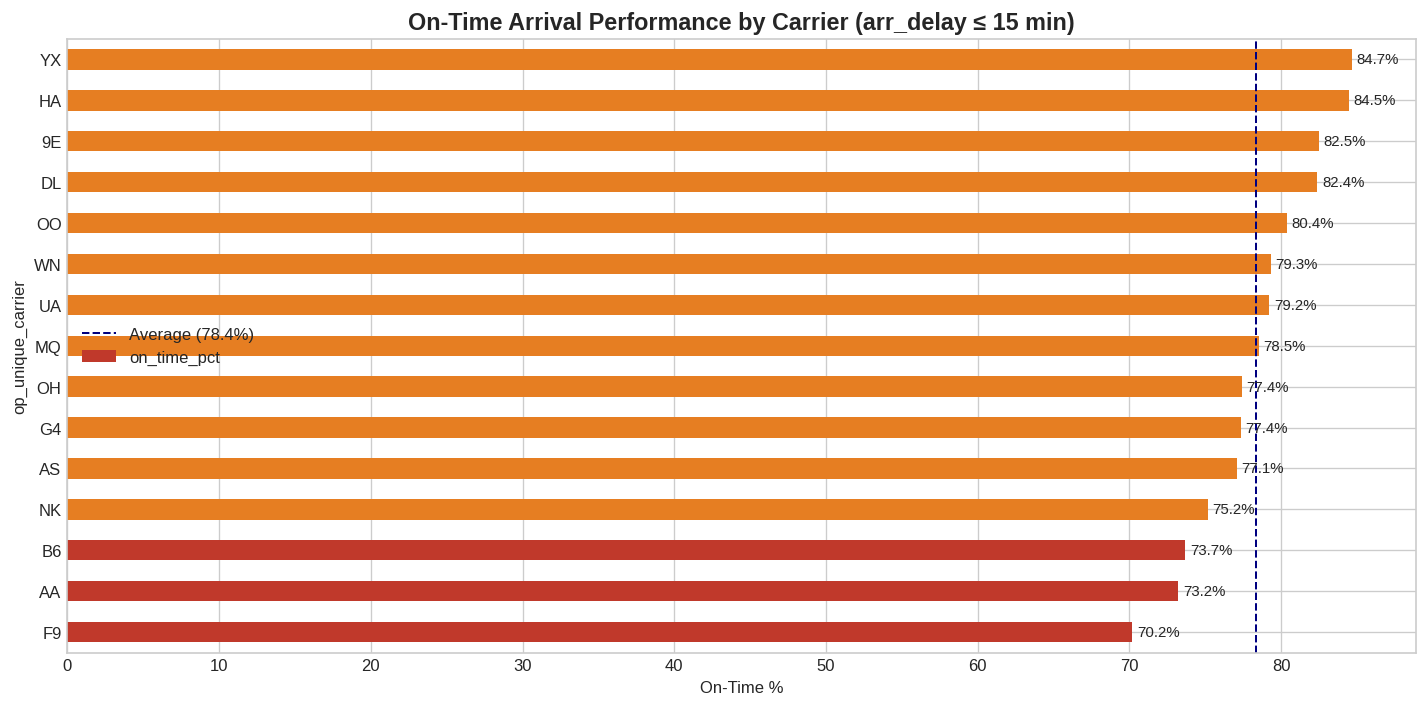

In [62]:
fig, ax = plt.subplots(**fig_kw)
otp_by_carrier.sort_values().plot(
    kind='barh', ax=ax,
    color=['#c0392b' if v < 75 else '#e67e22' if v < 85 else '#27ae60'
           for v in otp_by_carrier.sort_values()]
)
ax.set_title('On-Time Arrival Performance by Carrier (arr_delay ≤ 15 min)', fontsize=14, fontweight='bold')
ax.set_xlabel('On-Time %')
ax.axvline(otp_by_carrier.mean(), color='navy', linestyle='--', linewidth=1.2,
           label=f'Average ({otp_by_carrier.mean():.1f}%)')
ax.legend()
for bar, val in zip(ax.patches, otp_by_carrier.sort_values()):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Delay Cause: Frequency vs Severity

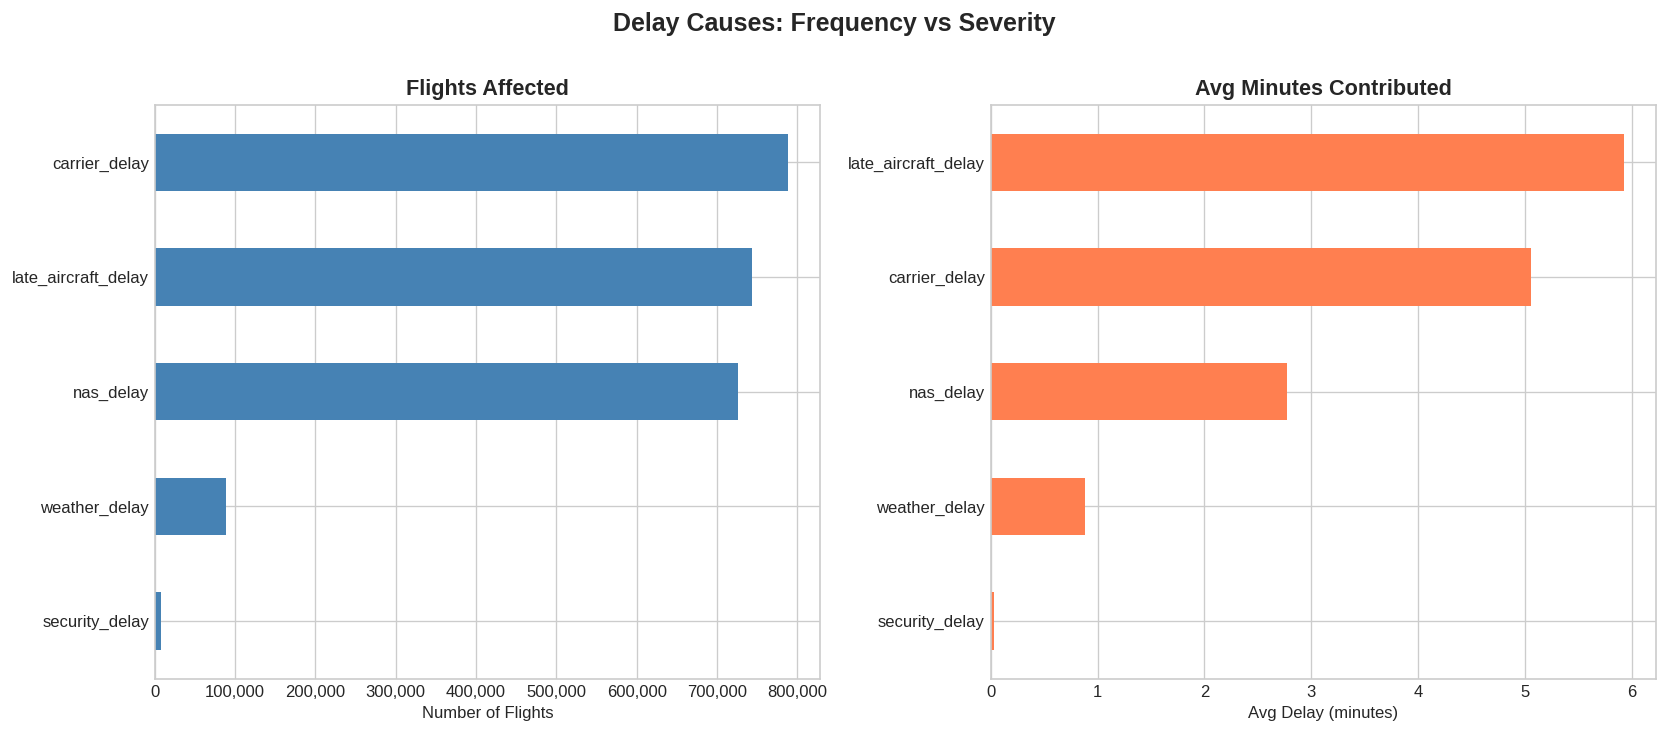

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=120)
delay_cause_counts.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Flights Affected', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Flights')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
avg_delay_by_cause.sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Avg Minutes Contributed', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Delay (minutes)')
plt.suptitle('Delay Causes: Frequency vs Severity', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Monthly Avg Delay Trend

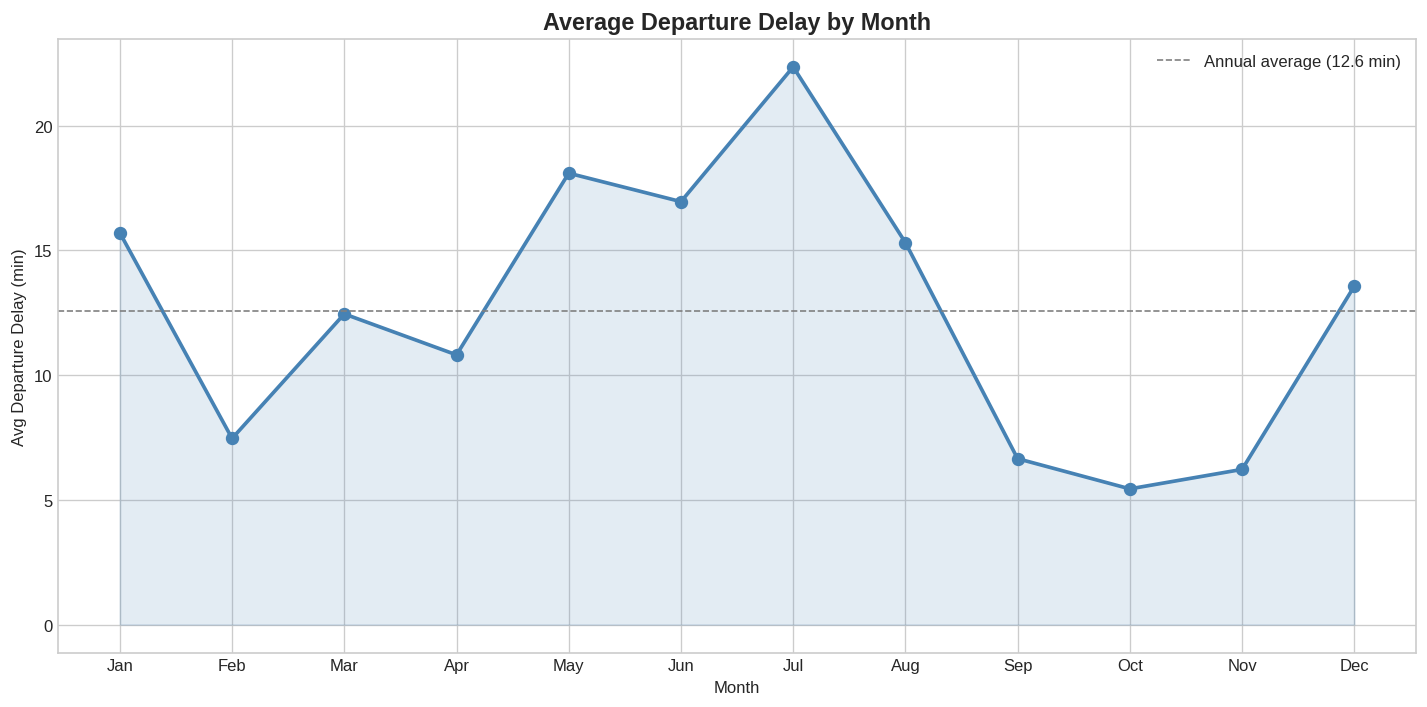

In [64]:
fig, ax = plt.subplots(**fig_kw)
plot_monthly = avg_delay_by_month.copy()
plot_monthly.index = plot_monthly.index.map(lambda m: pd.Timestamp(2024, m, 1).strftime('%b'))
ax.plot(plot_monthly.index, plot_monthly.values,
        marker='o', color='steelblue', linewidth=2.2, markersize=7)
ax.fill_between(plot_monthly.index, plot_monthly.values, alpha=0.15, color='steelblue')
ax.axhline(plot_monthly.mean(), linestyle='--', color='grey', linewidth=1,
           label=f'Annual average ({plot_monthly.mean():.1f} min)')
ax.set_title('Average Departure Delay by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Departure Delay (min)')
ax.legend()
plt.tight_layout()
plt.show()

Delay Heatmap: Hour of Day × Day of Week

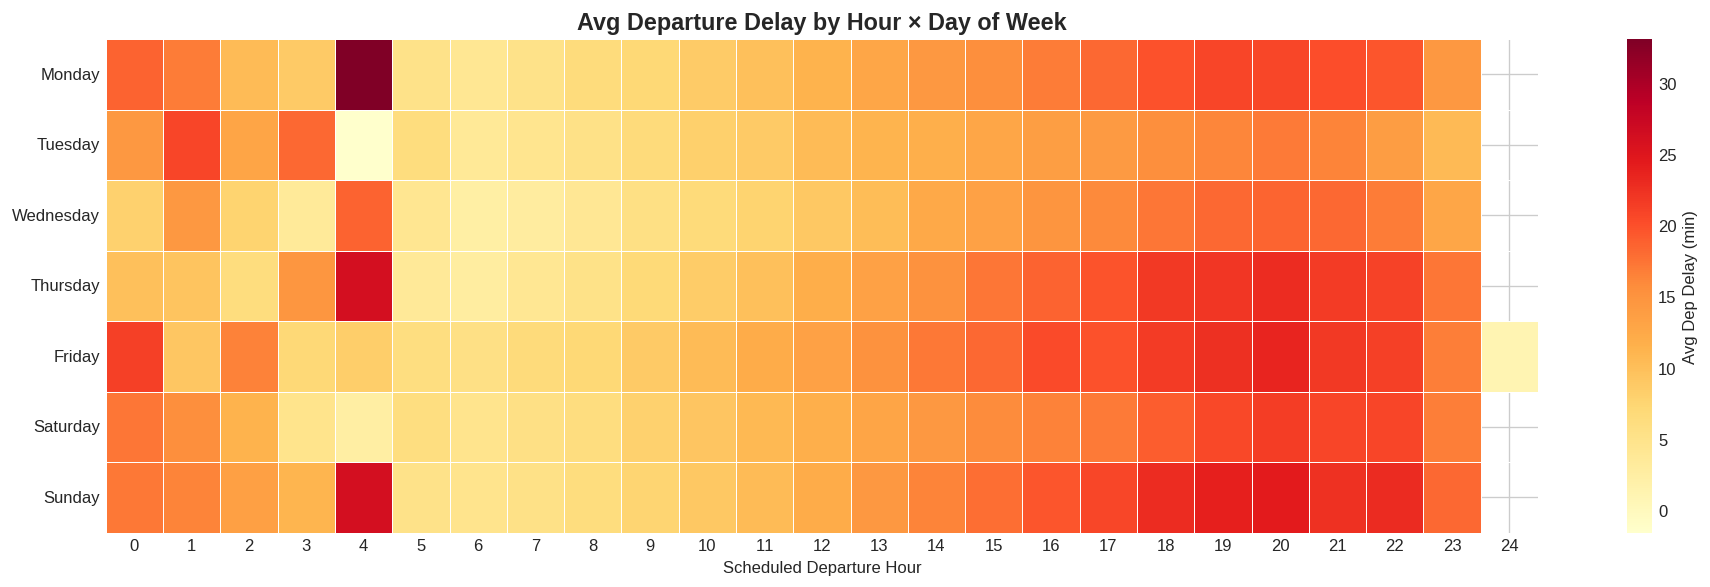

In [65]:
heatmap_data = (
    df.groupby(['day_of_week', 'scheduled_departure_hour'])['dep_delay']
    .mean()
    .unstack()
    .round(1)
)
heatmap_data.index = [day_names[d] for d in heatmap_data.index]
fig, ax = plt.subplots(figsize=(16, 5), dpi=120)
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Avg Dep Delay (min)'})
ax.set_title('Avg Departure Delay by Hour × Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Scheduled Departure Hour')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Airport Congestion Score by Hour

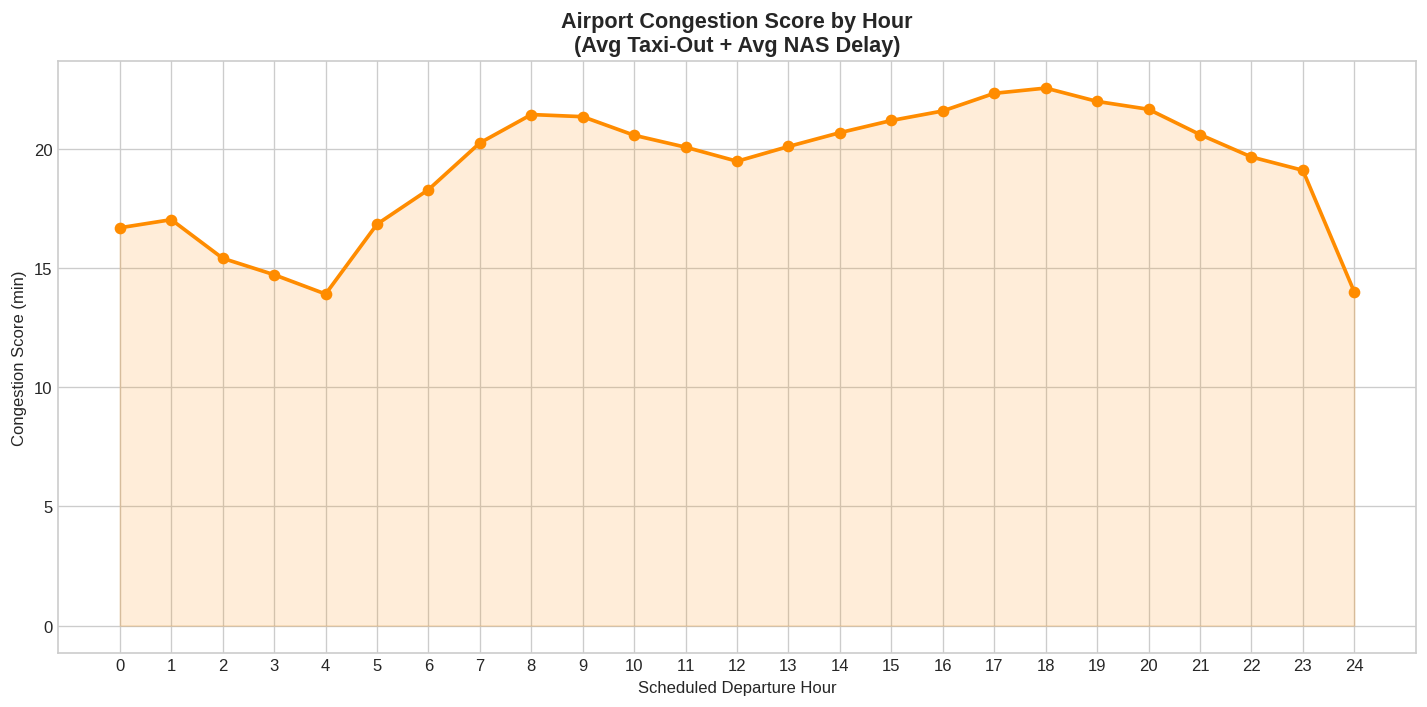

In [66]:
fig, ax = plt.subplots(**fig_kw)
ax.plot(congestion_by_hour.index, congestion_by_hour['congestion_score'],
        marker='o', color='darkorange', linewidth=2.2, markersize=6)
ax.fill_between(congestion_by_hour.index, congestion_by_hour['congestion_score'],
                alpha=0.15, color='darkorange')
ax.set_title('Airport Congestion Score by Hour\n(Avg Taxi-Out + Avg NAS Delay)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Scheduled Departure Hour')
ax.set_ylabel('Congestion Score (min)')
ax.set_xticks(congestion_by_hour.index)
plt.tight_layout()
plt.show()

Schedule Padding Effectiveness

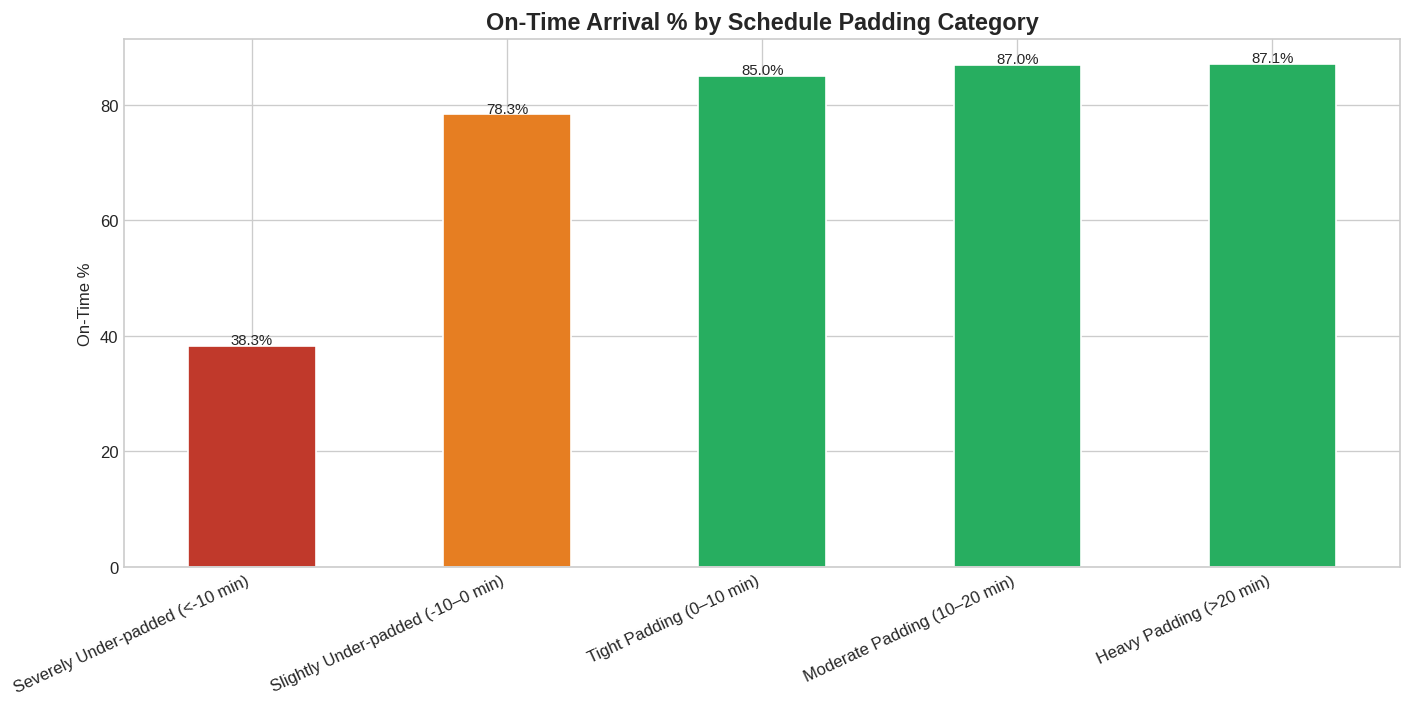

In [67]:
fig, ax = plt.subplots(**fig_kw)
padding_vs_otp['on_time_pct'].plot(
    kind='bar', ax=ax, edgecolor='white',
    color=['#c0392b' if v < 70 else '#e67e22' if v < 80 else '#27ae60'
           for v in padding_vs_otp['on_time_pct']]
)
ax.set_title('On-Time Arrival % by Schedule Padding Category', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('On-Time %')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
for bar, val in zip(ax.patches, padding_vs_otp['on_time_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Cancellation Rate by Carrier

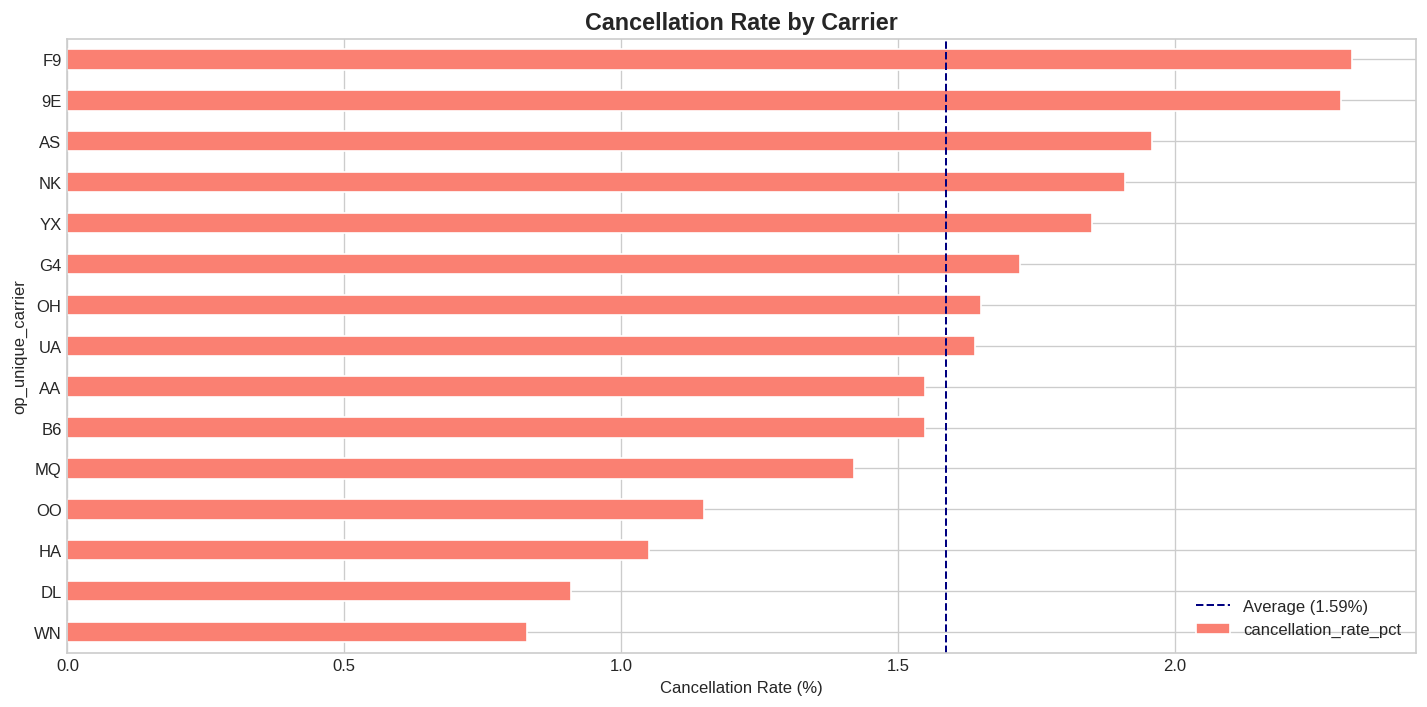

In [68]:
if 'cancelled' in df.columns:
    fig, ax = plt.subplots(**fig_kw)
    cancellation_by_carrier['cancellation_rate_pct'].sort_values().plot(
        kind='barh', ax=ax, color='salmon', edgecolor='white'
    )
    ax.axvline(cancellation_by_carrier['cancellation_rate_pct'].mean(), linestyle='--',
               color='navy', linewidth=1.2,
               label=f"Average ({cancellation_by_carrier['cancellation_rate_pct'].mean():.2f}%)")
    ax.set_title('Cancellation Rate by Carrier', fontsize=14, fontweight='bold')
    ax.set_xlabel('Cancellation Rate (%)')
    ax.legend()
    plt.tight_layout()
    plt.show()

Distance Band vs On-Time Performance

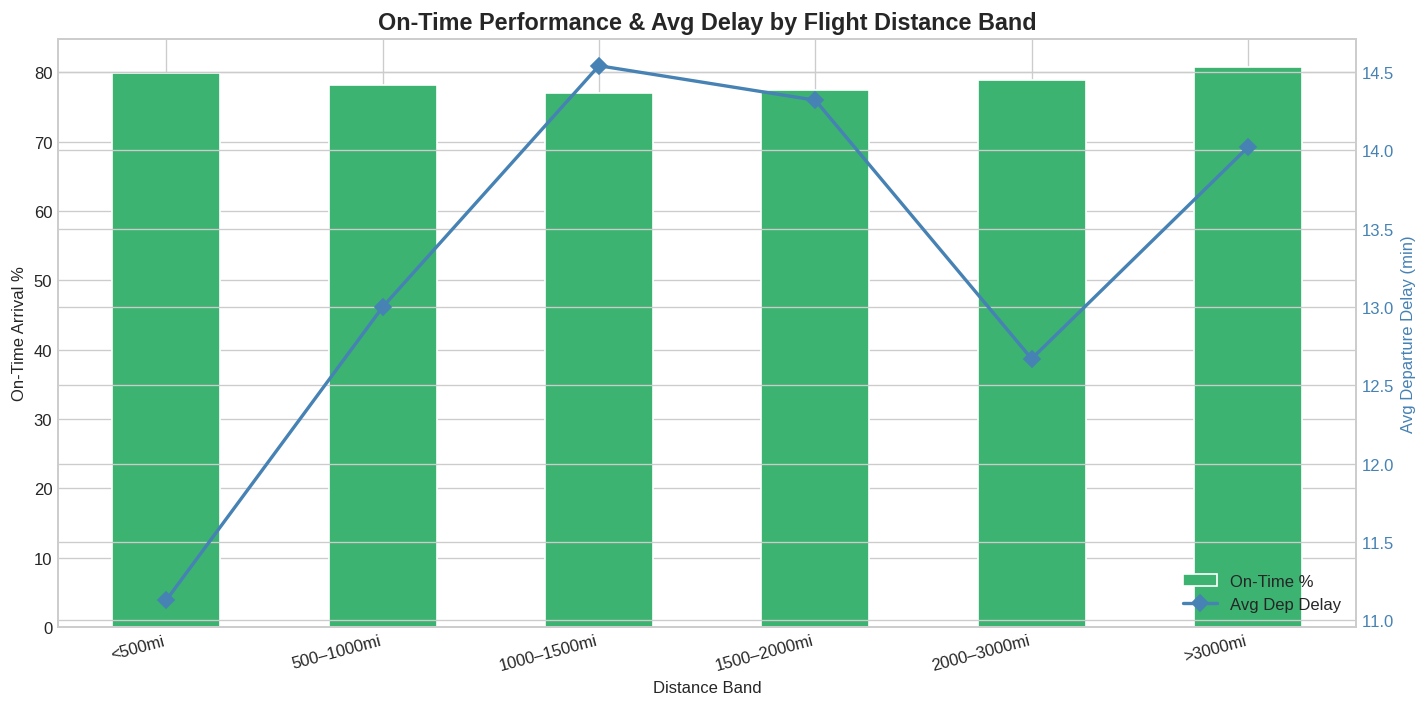

In [69]:
fig, ax = plt.subplots(**fig_kw)
dist_otp = dist_band_delay['on_time_pct']
dist_otp.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white', label='On-Time %')
ax.set_title('On-Time Performance & Avg Delay by Flight Distance Band',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Distance Band')
ax.set_ylabel('On-Time Arrival %')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax2 = ax.twinx()
dist_band_delay['avg_dep_delay'].plot(
    ax=ax2, color='steelblue', marker='D', linewidth=2, markersize=7, label='Avg Dep Delay')
ax2.set_ylabel('Avg Departure Delay (min)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.tight_layout()
plt.show()

**SECTION 11: SUMMARY OF KEY FINDINGS**

In [70]:
best_carrier_otp = otp_by_carrier.idxmax()
worst_carrier_otp = otp_by_carrier.idxmin()
most_congested = congestion_score['congestion_score'].idxmax()
peak_delay_hour = avg_delay_by_hour.idxmax()
best_delay_hour = avg_delay_by_hour.idxmin()
worst_season = avg_delay_by_season.idxmax()
best_season = avg_delay_by_season.idxmin()
top_catch_up = catch_up_factor.idxmax()
top_delay_cause = delay_cause_counts.idxmax()

In [71]:
cancel_line = ''
if 'cancelled' in df.columns:
    worst_cancel = cancellation_by_carrier['cancellation_rate_pct'].idxmax()
    cancel_line  = f"  Highest cancellation rate    : {worst_cancel}  ({cancellation_by_carrier.loc[worst_cancel, 'cancellation_rate_pct']:.2f}%)\n"

In [72]:
print("\n" + "=" * 60)
print("  KEY FINDINGS — FLIGHT DATA 2024")
print("=" * 60)
print(f"""
CARRIERS
  Best on-time performance   : {best_carrier_otp}  ({otp_by_carrier[best_carrier_otp]:.1f}%)
  Worst on-time performance  : {worst_carrier_otp}  ({otp_by_carrier[worst_carrier_otp]:.1f}%)
  Best catch-up factor       : {top_catch_up}  ({catch_up_factor[top_catch_up]:.1%} of late-departing flights still arrive on time)
{cancel_line}
AIRPORTS
  Most congested airport     : {most_congested}  (score: {congestion_score.loc[most_congested, 'congestion_score']:.1f} min)
  Busiest departure airport  : {busiest_airports.idxmax()}  ({busiest_airports.max():,} flights)

DELAYS
  Most common delay cause    : {top_delay_cause}  ({delay_cause_counts[top_delay_cause]:,} flights affected)
  Peak delay hour            : {peak_delay_hour}:00  (avg {avg_delay_by_hour[peak_delay_hour]:.1f} min departure delay)
  Best departure hour        : {best_delay_hour}:00  (avg {avg_delay_by_hour[best_delay_hour]:.1f} min departure delay)
  Worst season for delays    : {worst_season}  (avg {avg_delay_by_season[worst_season]:.1f} min)
  Best season for delays     : {best_season}  (avg {avg_delay_by_season[best_season]:.1f} min)

DATA QUALITY NOTES
  Outlier flights (>p99)     : {outlier_count:,} ({outlier_pct:.2f}% of dataset)
  Cause-of-delay null fill   : {', '.join(DELAY_COLS)}
  All averages above include outliers — see Section 3 for outlier-adjusted figures.
""")



  KEY FINDINGS — FLIGHT DATA 2024

CARRIERS
  Best on-time performance   : YX  (84.7%)
  Worst on-time performance  : F9  (70.2%)
  Best catch-up factor       : WN  (32.9% of late-departing flights still arrive on time)
  Highest cancellation rate    : F9  (2.32%)

AIRPORTS
  Most congested airport     : JFK  (score: 30.2 min)
  Busiest departure airport  : ATL  (341,910 flights)

DELAYS
  Most common delay cause    : carrier_delay  (788,965 flights affected)
  Peak delay hour            : 20:00  (avg 21.4 min departure delay)
  Best departure hour        : 24:00  (avg 1.0 min departure delay)
  Worst season for delays    : Summer  (avg 18.2 min)
  Best season for delays     : Autumn  (avg 6.1 min)

DATA QUALITY NOTES
  Outlier flights (>p99)     : 74,938 (1.06% of dataset)
  Cause-of-delay null fill   : carrier_delay, weather_delay, nas_delay, security_delay, late_aircraft_delay
  All averages above include outliers — see Section 3 for outlier-adjusted figures.

